In [10]:
import numpy as np

betas = np.load("betas_masked.npy")
mask = np.load("mask_voxel_indices.npy")
mds = np.load("mds_sample.npy")


x_samples = mds[:, 0]
y_samples = mds[:, 1]

False
1: Optimized Parameters [A, x0, y0, sigma]: (0.019553784281015396, 0, 0, 100)
Variance Explained (R²): -0.0000
Variance Explained 2 (R²): -0.0000


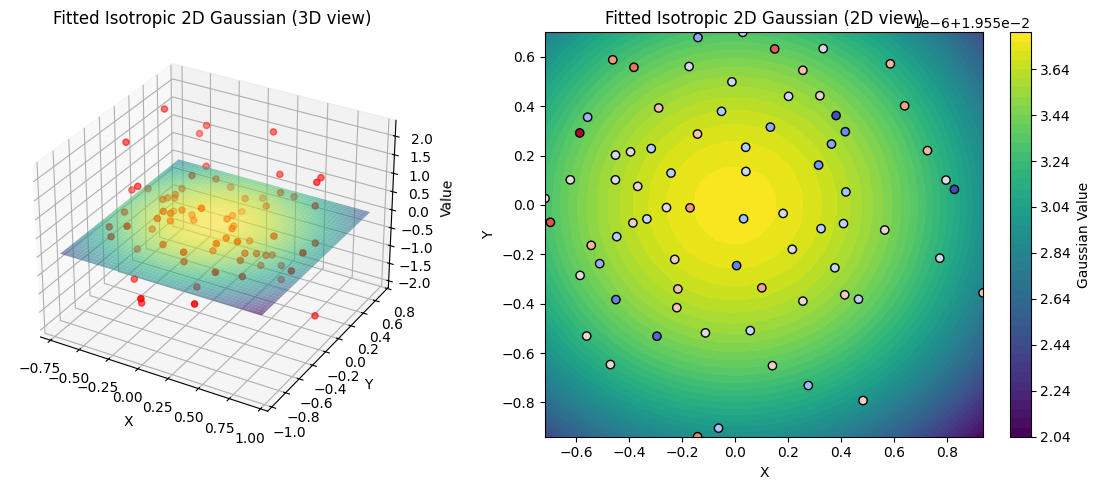

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import curve_fit

# ------------------------------------------------------------------
# 1) Define an isotropic 2D Gaussian in Cartesian space
#    (center = (x0, y0), single spread = sigma for both x and y)
# ------------------------------------------------------------------
def gaussian_2d_cartesian_isotropic(coords, A, x0, y0, sigma):
    """
    coords: tuple of (x, y) arrays
    A:       amplitude (peak value)
    x0, y0:  center of the Gaussian in Cartesian coordinates
    sigma:   standard deviation (equal in x and y)
    """
    x, y = coords
    exponent = -((x - x0)**2 + (y - y0)**2) / (2 * sigma**2)
    return A * np.exp(exponent)

# ------------------------------------------------------------------
# 2) Fit the isotropic 2D Gaussian using curve_fit
# ------------------------------------------------------------------
def fit_cartesian_gaussian_isotropic(x_vals, y_vals, target_values):
    """
    x_vals, y_vals: 1D arrays of sample coordinates
    target_values:   1D array of values at (x_vals, y_vals)
    Returns:
      popt: optimized parameters [A, x0, y0, sigma]
    """
    # Initial guess:
    #   - Amplitude: max(target_values)
    #   - Center: mean(x), mean(y)
    #   - Spread: use the average of the standard deviations in x and y (or one of them)
    A0 = np.max(target_values)
    x0 = np.mean(x_vals)
    y0 = np.mean(y_vals)
    sigma0 = max(np.std(x_vals), np.std(y_vals), 1e-6)

    # initial_guess = [np.random.uniform(0.1, A0), x0, y0, sigma0]
    initial_guess = [np.random.uniform(0.1, A0), np.random.uniform(-1, 1), np.random.uniform(-1, 1), sigma0]

    
    # Set bounds: amplitude >= 0, sigma > 0
    lower_bounds = [0, -1.1, -1.1, 1e-6]
    upper_bounds = [np.inf,  1.1,  1.1, np.inf]
    
    popt, pcov = curve_fit(
        gaussian_2d_cartesian_isotropic,
        (x_vals, y_vals),
        target_values,
        p0=initial_guess,
        bounds=(lower_bounds, upper_bounds),
        maxfev=2000
    )
    return popt



# ------------------------------------------------------------------
# 2) Fit the isotropic 2D Gaussian using curve_fit
# ------------------------------------------------------------------
def fit_cartesian_gaussian_isotropic(x_vals, y_vals, target_values):
    """
    x_vals, y_vals: 1D arrays of sample coordinates
    target_values:   1D array of values at (x_vals, y_vals)
    Returns:
      popt: optimized parameters [A, x0, y0, sigma]
    """
    # Initial guess:
    #   - Amplitude: max(target_values)
    #   - Center: mean(x), mean(y)
    #   - Spread: use the average of the standard deviations in x and y (or one of them)
    A0 = np.max(target_values)
    x0 = np.mean(x_vals)
    y0 = np.mean(y_vals)
    sigma0 = max(np.std(x_vals), np.std(y_vals), 1e-6)

    # initial_guess = [np.random.uniform(0.1, A0), x0, y0, sigma0]
    initial_guess = [
        np.random.uniform(0.1, A0),
        np.random.uniform(-1, 1),
        np.random.uniform(-1, 1),
        sigma0,
    ]

    # print(initial_guess)

    # Set bounds: amplitude >= 0, sigma > 0
    lower_bounds = [0, -1.1, -1.1, 1e-6]
    upper_bounds = [np.inf, 1.1, 1.1, np.inf]

    attempt = 1
    solved = False
    while attempt <= 3 and not solved:
        try:
            popt, pcov = curve_fit(
                gaussian_2d_cartesian_isotropic,
                (x_vals, y_vals),
                target_values,
                p0=initial_guess,
                bounds=(lower_bounds, upper_bounds),
                maxfev=2000,
            )
            solved = True
        except:
            if attempt > 3:
                print(f"{attempt=}")

            attempt += 1

    if solved:
        return popt, solved
    else:
        popt = np.mean(target_values).item(), 0, 0, 100
        # raise RuntimeError
        return popt, solved

# ------------------------------------------------------------------
# 3) Compute Variance Explained (R²)
# ------------------------------------------------------------------
def variance_explained(y_true, y_pred):
    """
    Returns R^2 = 1 - (SS_res / SS_tot).
    In the worst-case scenario the Gaussian can mimic a constant (the mean),
    so the model will never be worse than predicting the mean.
    """
    ss_total = np.sum((y_true - np.mean(y_true))**2)  # total variance
    ss_residual = np.sum((y_true - y_pred)**2)         # residual variance
    r_squared = 1 - (ss_residual / ss_total)
    return r_squared

# ------------------------------------------------------------------
# 4) Visualize the fit in Cartesian space
# ------------------------------------------------------------------
def plot_results_cartesian(popt, x_samples, y_samples, target_values, predicted_values):
    """
    Plots both a 3D surface and a 2D heatmap of the fitted 2D Gaussian.
    popt = [A, x0, y0, sigma]
    """
    # Create a meshgrid covering the range of your data
    x_min, x_max = np.min(x_samples), np.max(x_samples)
    y_min, y_max = np.min(y_samples), np.max(y_samples)
    X_grid, Y_grid = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )
    
    # Evaluate the fitted Gaussian on the grid
    Z_grid = gaussian_2d_cartesian_isotropic((X_grid, Y_grid), *popt)

    fig = plt.figure(figsize=(12, 5))
    
    # --- 3D Surface Plot ---
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(x_samples, y_samples, target_values, color='r', label="Data Points")
    ax1.plot_surface(X_grid, Y_grid, Z_grid, cmap="viridis", alpha=0.6)
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Value")
    ax1.set_title("Fitted Isotropic 2D Gaussian (3D view)")

    # --- 2D Contour/Heatmap ---
    ax2 = fig.add_subplot(122)
    contour = ax2.contourf(X_grid, Y_grid, Z_grid, levels=50, cmap="viridis")
    scatter = ax2.scatter(x_samples, y_samples, c=target_values, cmap="coolwarm", edgecolors='k')
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_title("Fitted Isotropic 2D Gaussian (2D view)")
    plt.colorbar(contour, ax=ax2, label='Gaussian Value')
    
    plt.tight_layout()
    plt.show()


def variance_explained_2(A, x0, y0, sigma, target_values):
    x_trials, y_trials = (
        mds.T[0, :],
        mds.T[1, :],
    )  # Extract trial coordinates

    # Compute Gaussian amplitude for each trial at this voxel
    predicted_activity = A * np.exp(
        -((x_trials - x0) ** 2 + (y_trials - y0) ** 2) / (2 * sigma**2)
    )


    

    residual_sum_squares = np.sum(
        (predicted_activity - target_values) ** 2
    )

    total_sum_squares = np.sum(
                    (target_values - target_values.mean(axis=0)) ** 2, 
                )

    var = 1 - (
                    residual_sum_squares / (total_sum_squares)
                )

    return var
# ------------------------------------------------------------------
# 5) Example usage (replace with your own data)
# ------------------------------------------------------------------
# Assume x_samples, y_samples, and target_values are defined.
# For example:
# x_samples = mds[:, 0]
# y_samples = mds[:, 1]
# target_values = betas[4, :]

# Fit the isotropic 2D Gaussian
for i in range(betas.shape[0]):

    if i > 5: 
        break


    target_values = betas[i, :]
    popt, solved = fit_cartesian_gaussian_isotropic(x_samples, y_samples, target_values)

    # popt = np.mean(target_values), 0, 0, 100



    # Predict values using the optimized model
    predicted_values = gaussian_2d_cartesian_isotropic((x_samples, y_samples), *popt)

    # Compute Variance Explained (R²)
    r2 = variance_explained(target_values, predicted_values)

    if r2 < 0 or r2 > 0.3:
        print(solved)
        A, x0, y0, sigma = popt 
        print(f"{i}: Optimized Parameters [A, x0, y0, sigma]:", popt)
        print(f"Variance Explained (R²): {r2:.4f}")


        var_2 = variance_explained_2(A, x0, y0, sigma, target_values)
        print(f"Variance Explained 2 (R²): {var_2:.4f}")


        # Plot the results
        plot_results_cartesian(popt, x_samples, y_samples, target_values, predicted_values)


In [18]:
# Step 1: Convert Cartesian (x, y) to Polar (r, θ)
def cartesian_to_polar(x, y):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return r, theta

# Step 2: Define the 2D Gaussian in Polar Space
def polar_gaussian(params, r, theta):
    A, mu_r, sigma_r, mu_theta, sigma_theta = params
    return A * np.exp(-((r - mu_r) ** 2 / (2 * sigma_r ** 2)) - ((theta - mu_theta) ** 2 / (2 * sigma_theta ** 2)))


import numpy as np
from scipy.optimize import curve_fit

# ------------------------------------------------------------------
# 1) Define an isotropic 2D Gaussian in polar coordinates
#    (center = (r0, theta0), single spread = sigma)
# ------------------------------------------------------------------
def gaussian_2d_polar(coords, A, r0, theta0, sigma):
    """
    coords: tuple of (r, theta) arrays
    A:       amplitude (peak value)
    r0, theta0: center of the Gaussian in polar coordinates
    sigma:   standard deviation (equal in all directions)
    
    The distance d between a point (r, theta) and the center (r0, theta0)
    is given by the law of cosines:
    
        d = sqrt(r**2 + r0**2 - 2*r*r0*cos(theta - theta0))
    """
    r, theta = coords
    d = np.sqrt(r**2 + r0**2 - 2 * r * r0 * np.cos(theta - theta0))
    exponent = -(d**2) / (2 * sigma**2)
    return A * np.exp(exponent)

# ------------------------------------------------------------------
# 2) Fit the isotropic 2D Gaussian using curve_fit in polar coordinates
# ------------------------------------------------------------------
def fit_polar_gaussian_isotropic(r_vals, theta_vals, target_values):
    """
    r_vals, theta_vals: 1D arrays of sample polar coordinates (r and theta)
    target_values:      1D array of values at (r_vals, theta_vals)
    
    Returns:
      popt: optimized parameters [A, r0, theta0, sigma]
    """
    # Initial guess:
    #   - Amplitude: max(target_values)
    #   - Center: mean of r and theta values (for theta, note this is a rough guess)
    #   - Spread: use the standard deviation of r (or a small value to avoid zero)
    A0 = np.max(target_values)
    r0_guess = np.mean(r_vals)
    theta0_guess = np.mean(theta_vals)
    sigma0 = max(np.std(r_vals), 1e-6)

    # Example of randomized initial guess for variability
    
    
    # Set bounds: amplitude >= 0, sigma > 0, r0 >= 0, theta0 within [-pi, pi]
    lower_bounds = [0, 0, -np.pi, 1e-6]
    upper_bounds = [np.inf, 1.0, np.pi, 100]

    attempt = 1
    solved = False
    while attempt <= 3 and not solved:
        initial_guess = [
            np.random.uniform(0.1, A0),
            np.random.uniform(0, np.max(r_vals)),    # r0 should be non-negative
            np.random.uniform(-np.pi, np.pi),          # theta0 in radians
            sigma0
        ]
        try:
            popt, pcov = curve_fit(
                gaussian_2d_polar,
                (r_vals, theta_vals),
                target_values,
                p0=initial_guess,
                bounds=(lower_bounds, upper_bounds),
                maxfev=2000
            )

            A, r0, theta0, sigma = popt
            x0 = r0 * np.cos(theta0)
            y0 = r0 * np.sin(theta0)
            return [A.item(), x0.item(), y0.item(), sigma.item()], True
        except:
            if attempt > 3:
                print(f"{attempt=}")

            attempt += 1

    if solved:
        return popt, solved
    else:
        popt = np.mean(target_values).item(), 0, 0, 100
        # raise RuntimeError
        return popt, solved

In [ ]:



# ------------------------------------------------------------------
# 2) Fit the isotropic 2D Gaussian using curve_fit
# ------------------------------------------------------------------
def fit_gaussian_isotropic(x_vals, y_vals, target_values, polar: bool):
    """
    x_vals, y_vals: 1D arrays of sample coordinates
    target_values:   1D array of values at (x_vals, y_vals)
    Returns:
      popt: optimized parameters [A, x0, y0, sigma]
    """

    A0 = np.max(target_values)

    if polar:
        r_samples = np.sqrt(x_samples**2 + y_samples**2)
        theta_samples = np.arctan2(y_samples, x_samples)
        sigma0 = max(np.std(r_samples), 1e-6)
                
        # Set bounds: amplitude >= 0, sigma > 0, r0 >= 0, theta0 within [-pi, pi]
        lower_bounds = [0, 0, -np.pi, 1e-6]
        upper_bounds = [np.inf, 1.0, np.pi, 100]

        


    else:
        sigma0 = max(np.std(x_vals), np.std(y_vals), 1e-6)        
        # Set bounds: amplitude >= 0, sigma > 0
        lower_bounds = [0, -1.1, -1.1, 1e-6]
        upper_bounds = [np.inf, 1.1, 1.1, 100]


    attempt = 1
    solved = False
    while attempt <= 3 and not solved:
        try:
            if polar:
                initial_guess = [
                    np.random.uniform(0.1, A0),
                    np.random.uniform(0, 1),    
                    np.random.uniform(-np.pi, np.pi),          # theta0 in radians
                    sigma0
                ]


                popt, pcov = curve_fit(
                    gaussian_2d_cartesian_isotropic,
                    (x_vals, y_vals),
                    target_values,
                    p0=initial_guess,
                    bounds=(lower_bounds, upper_bounds),
                    maxfev=2000,
                )
            else:
                initial_guess = [
                    np.random.uniform(0.1, A0),
                    np.random.uniform(-1, 1),
                    np.random.uniform(-1, 1),
                    sigma0,
                ]

                popt, pcov = curve_fit(gaussian_2d_polar,
                    (r_samples, theta_samples),
                    target_values,
                    p0=initial_guess,
                    bounds=(lower_bounds, upper_bounds),
                    maxfev=2000
                )

                A, r0, theta0, sigma = popt
                x0 = r0 * np.cos(theta0)
                y0 = r0 * np.sin(theta0)
                popt = [A.item(), x0.item(), y0.item(), sigma.item()]
            
            solved = True
        except:
            if attempt > 3:
                print(f"{attempt=}")

            attempt += 1

    if solved:
        return popt, solved
    else:
        popt = np.mean(target_values).item(), 0, 0, 100
        # raise RuntimeError
        return popt, solved

4: Optimized Parameters [A, x0, y0, sigma]: [0.18494373757112634, 0.6713674711689462, -0.14019886499489478, 0.015176179522786366]
Variance Explained (R²): -0.0022
Variance Explained 2 (R²): -0.0022


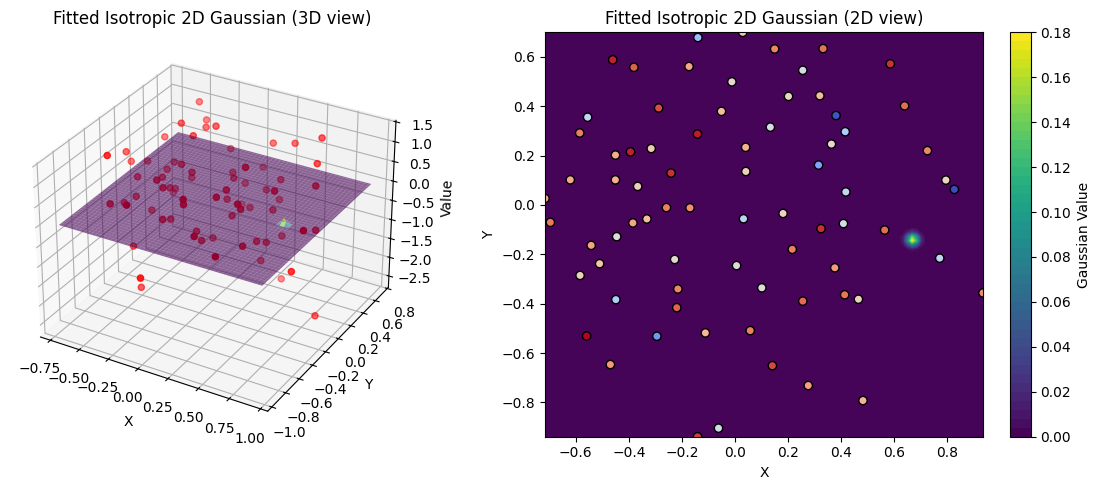

In [25]:
r_samples = np.sqrt(x_samples**2 + y_samples**2)
theta_samples = np.arctan2(y_samples, x_samples)

# Now use the polar coordinate arrays to fit the Gaussian in polar coordinates


for i in range(betas.shape[0]):

    if i > 5: 
        break


    target_values = betas[i, :]
    popt, solved = fit_polar_gaussian_isotropic(r_samples, theta_samples, target_values)


    # popt = np.mean(target_values), 0, 0, 100


    A, x0, y0, sigma = popt 
    # Predict values using the optimized model
    predicted_values = gaussian_2d_cartesian_isotropic((x_samples, y_samples), A, x0, y0, sigma)

    # Compute Variance Explained (R²)
    r2 = variance_explained(target_values, predicted_values)

    if r2 < 0 or r2 > 0.3:
        A, x0, y0, sigma = popt 
        print(f"{i}: Optimized Parameters [A, x0, y0, sigma]:", popt)
        print(f"Variance Explained (R²): {r2:.4f}")


        var_2 = variance_explained_2(A, x0, y0, sigma, target_values)
        print(f"Variance Explained 2 (R²): {var_2:.4f}")


        # Plot the results
        plot_results_cartesian(popt, x_samples, y_samples, target_values, predicted_values)

In [26]:
import numpy as np
from scipy.optimize import curve_fit

class Gaussian2DFitter:
    def __init__(self, use_polar: bool = False):
        """
        Initialize the fitter.
        
        Parameters:
          use_polar: if True, the fitting is performed in polar coordinates;
                     if False, Cartesian coordinates are used.
        """
        self.use_polar = use_polar
        self.params = None  # Will hold [A, x0, y0, sigma]
        self.solved = False

    @staticmethod
    def gaussian_2d_cartesian(coords, A, x0, y0, sigma):
        """
        Isotropic 2D Gaussian in Cartesian coordinates.
        
        Parameters:
          coords: tuple of (x, y) arrays
          A: amplitude
          x0, y0: center of the Gaussian
          sigma: standard deviation
        """
        x, y = coords
        exponent = -(((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))
        return A * np.exp(exponent)

    @staticmethod
    def gaussian_2d_polar(coords, A, r0, theta0, sigma):
        """
        Isotropic 2D Gaussian in polar coordinates.
        
        Parameters:
          coords: tuple of (r, theta) arrays
          A: amplitude
          r0, theta0: center in polar coordinates
          sigma: standard deviation
          
        The distance between a point (r, theta) and the center (r0, theta0)
        is computed via the law of cosines:
        
            d = sqrt(r**2 + r0**2 - 2*r*r0*cos(theta - theta0))
        """
        r, theta = coords
        d = np.sqrt(r**2 + r0**2 - 2 * r * r0 * np.cos(theta - theta0))
        exponent = -(d**2) / (2 * sigma**2)
        return A * np.exp(exponent)

    def fit(self, x_vals, y_vals, target_values):
        """
        Fit the isotropic 2D Gaussian to the provided data.
        
        Parameters:
          x_vals, y_vals: 1D arrays of sample coordinates
          target_values: 1D array of values at (x_vals, y_vals)
          
        Returns:
          (popt, solved) where popt is the optimized parameters [A, x0, y0, sigma]
          and solved is a boolean indicating whether the fit succeeded.
        """
        A0 = np.max(target_values)
        attempt = 1
        solved = False

        if self.use_polar:
            # Convert the Cartesian samples to polar coordinates.
            r_samples = np.sqrt(x_vals**2 + y_vals**2)
            theta_samples = np.arctan2(y_vals, x_vals)
            sigma0 = max(np.std(r_samples), 1e-6)
            # Set bounds: amplitude >= 0, r0 in [0,1] (unit circle), theta0 in [-pi, pi], sigma > 0.
            lower_bounds = [0, 0, -np.pi, 1e-6]
            upper_bounds = [np.inf, 1.0, np.pi, 100]
        else:
            sigma0 = max(np.std(x_vals), np.std(y_vals), 1e-6)
            # Bounds for Cartesian fit: amplitude >= 0, x0,y0 within [-1.1, 1.1], sigma > 0.
            lower_bounds = [0, -1.1, -1.1, 1e-6]
            upper_bounds = [np.inf, 1.1, 1.1, 100]

        while attempt <= 3 and not solved:
            try:
                if self.use_polar:
                    # Initial guess for polar parameters: [A, r0, theta0, sigma]
                    initial_guess = [
                        np.random.uniform(0.1, A0),
                        np.random.uniform(0, 1),
                        np.random.uniform(-np.pi, np.pi),
                        sigma0
                    ]
                    # Fit using the polar version of the Gaussian.
                    popt, pcov = curve_fit(
                        Gaussian2DFitter.gaussian_2d_polar,
                        (r_samples, theta_samples),
                        target_values,
                        p0=initial_guess,
                        bounds=(lower_bounds, upper_bounds),
                        maxfev=2000
                    )
                    # Convert the polar center to Cartesian coordinates.
                    A, r0, theta0, sigma = popt
                    x0 = r0 * np.cos(theta0)
                    y0 = r0 * np.sin(theta0)
                    self.params = [A.item(), x0.item(), y0.item(), sigma.item()]
                else:
                    # Initial guess for Cartesian parameters: [A, x0, y0, sigma]
                    initial_guess = [
                        np.random.uniform(0.1, A0),
                        np.random.uniform(-1, 1),
                        np.random.uniform(-1, 1),
                        sigma0,
                    ]
                    popt, pcov = curve_fit(
                        Gaussian2DFitter.gaussian_2d_cartesian,
                        (x_vals, y_vals),
                        target_values,
                        p0=initial_guess,
                        bounds=(lower_bounds, upper_bounds),
                        maxfev=2000
                    )
                    self.params = popt
                solved = True
            except Exception as e:
                attempt += 1
                if attempt > 3:
                    print("Fitting failed after 3 attempts:", e)
        self.solved = solved

        # In case of failure, return a fallback set of parameters.
        if not solved:
            self.params = [np.mean(target_values).item(), 0, 0, 100]
        return self.params, solved

    def predict(self, coords, input_polar: bool = False):
        """
        Predict the Gaussian value at the provided coordinates.
        
        Parameters:
          coords: tuple of coordinate arrays.
                  If input_polar is False, coords should be (x, y).
                  If input_polar is True, coords should be (r, theta).
          input_polar: If True, interpret the input coordinates as polar.
        
        Returns:
          The predicted Gaussian value at the provided points.
          
        Note: Even if the fitting was performed in polar coordinates, the stored
        parameters are in Cartesian form. Thus, predictions are made via the
        Cartesian Gaussian function.
        """
        if not self.solved or self.params is None:
            raise ValueError("Model has not been successfully fitted yet.")

        A, x0, y0, sigma = self.params

        # Convert input coordinates to Cartesian if they are provided in polar form.
        if input_polar:
            r, theta = coords
            x = r * np.cos(theta)
            y = r * np.sin(theta)
            coords_cartesian = (x, y)
        else:
            coords_cartesian = coords

        return Gaussian2DFitter.gaussian_2d_cartesian(coords_cartesian, A, x0, y0, sigma)
    

    def plot_fit_cartesian(self, x_samples, y_samples, target_values):
        """
        Visualize the fitted Gaussian in Cartesian space using both a 3D surface and a 2D contour plot.
        
        Parameters:
          x_samples, y_samples: 1D arrays of the sample coordinates (Cartesian)
          target_values: 1D array of the measured values at (x_samples, y_samples)
        """
        if not self.solved or self.params is None:
            raise ValueError("Model has not been successfully fitted yet.")

        popt = self.params  # [A, x0, y0, sigma]

        # Create a meshgrid covering the range of your data
        x_min, x_max = np.min(x_samples), np.max(x_samples)
        y_min, y_max = np.min(y_samples), np.max(y_samples)
        X_grid, Y_grid = np.meshgrid(
            np.linspace(x_min, x_max, 100),
            np.linspace(y_min, y_max, 100)
        )
        
        # Evaluate the fitted Gaussian on the grid using the Cartesian function.
        Z_grid = Gaussian2DFitter.gaussian_2d_cartesian((X_grid, Y_grid), *popt)

        fig = plt.figure(figsize=(12, 5))
        
        # --- 3D Surface Plot ---
        ax1 = fig.add_subplot(121, projection='3d')
        ax1.scatter(x_samples, y_samples, target_values, color='r', label="Data Points")
        ax1.plot_surface(X_grid, Y_grid, Z_grid, cmap="viridis", alpha=0.6)
        ax1.set_xlabel("X")
        ax1.set_ylabel("Y")
        ax1.set_zlabel("Value")
        ax1.set_title("Fitted Isotropic 2D Gaussian (3D view)")
    
        # --- 2D Contour/Heatmap ---
        ax2 = fig.add_subplot(122)
        contour = ax2.contourf(X_grid, Y_grid, Z_grid, levels=50, cmap="viridis")
        ax2.scatter(x_samples, y_samples, c=target_values, cmap="coolwarm", edgecolors='k')
        ax2.set_xlabel("X")
        ax2.set_ylabel("Y")
        ax2.set_title("Fitted Isotropic 2D Gaussian (2D view)")
        plt.colorbar(contour, ax=ax2, label='Gaussian Value')
        
        plt.tight_layout()
        plt.show()

# Example usage:
# Suppose you have your data in x_samples, y_samples, and target_values:
# fitter = Gaussian2DFitter(use_polar=True)
# popt, solved = fitter.fit(x_samples, y_samples, target_values)
# To predict, for example using Cartesian inputs:
# predicted_vals = fitter.predict((x_samples, y_samples))
# Or if you want to supply polar coordinates:
# r_samples = np.sqrt(x_samples**2 + y_samples**2)
# theta_samples = np.arctan2(y_samples, x_samples)
# predicted_vals = fitter.predict((r_samples, theta_samples), input_polar=True)


In [ ]:
for i in range(betas.shape[0]):

    if i > 5: 
        break


    target_values = betas[i, :]

    fitter = Gaussian2DFitter(use_polar=False)
    fitter_polar = Gaussian2DFitter(use_polar=True)

    fitter.fit(x_samples, y_samples, target_values)
    fitter_polar.fit(x_samples, y_samples, target_values)

